# ELA + Metadata Image Forgery Detection
### Kaggle – GPU T4 x2 Edition

In [1]:
import os, tensorflow as tf

# ── Multi-GPU MirroredStrategy for T4 x2 ──────────────────────────────
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs available: {strategy.num_replicas_in_sync}")


2026-03-25 04:40:00.080983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774413600.486125      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774413600.652268      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774413601.776697      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774413601.776741      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774413601.776744      55 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs available: 2


I0000 00:00:1774413640.794115      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774413640.797098      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Dataset Paths
CASIA 2.0 is attached as a Kaggle dataset. Adjust `DATASET_SLUG` if your dataset name differs.

In [2]:
# ── CASIA 2.0 Kaggle dataset root ─────────────────────────────────────
# Typical Kaggle input path: /kaggle/input/<dataset-slug>/
DATASET_ROOT = '/kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2'   # <-- change slug if needed

Real_path     = os.path.join(DATASET_ROOT, 'Au/')
Tampered_path = os.path.join(DATASET_ROOT, 'Tp/')

# ── Output dir (persists after session) ───────────────────────────────
OUTPUT_DIR  = '/kaggle/working/ela_outputs'
ELA_DATA    = os.path.join(OUTPUT_DIR, 'ELA_Data')
MODEL_PATH  = os.path.join(OUTPUT_DIR, 'ELA_Model.keras')
BEST_MODEL  = os.path.join(OUTPUT_DIR, 'best_model.keras')

os.makedirs(ELA_DATA, exist_ok=True)
print("Real path exists    :", os.path.isdir(Real_path))
print("Tampered path exists:", os.path.isdir(Tampered_path))
print("Output dir          :", OUTPUT_DIR)


Real path exists    : True
Tampered path exists: True
Output dir          : /kaggle/working/ela_outputs


## Imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         LearningRateScheduler, ReduceLROnPlateau)
from tensorflow.keras import Model


## ELA Helper
**ELA** re-saves the image at a lower JPEG quality and computes the absolute difference. Tampered regions show higher residual energy.

In [4]:
def convert_to_ela_image(path, quality=90):
    """Return a PIL ELA image; works with any PIL-readable format."""
    import tempfile
    image = Image.open(path).convert('RGB')
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        tmp_path = tmp.name
    image.save(tmp_path, 'JPEG', quality=quality)
    temp_image = Image.open(tmp_path)

    ela_image = ImageChops.difference(image, temp_image)
    extrema   = ela_image.getextrema()
    max_diff  = sum(ex[1] for ex in extrema) / 3
    if max_diff == 0:
        max_diff = 1
    scale     = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    os.remove(tmp_path)
    return ela_image


## ELA Visualisation – Real Images

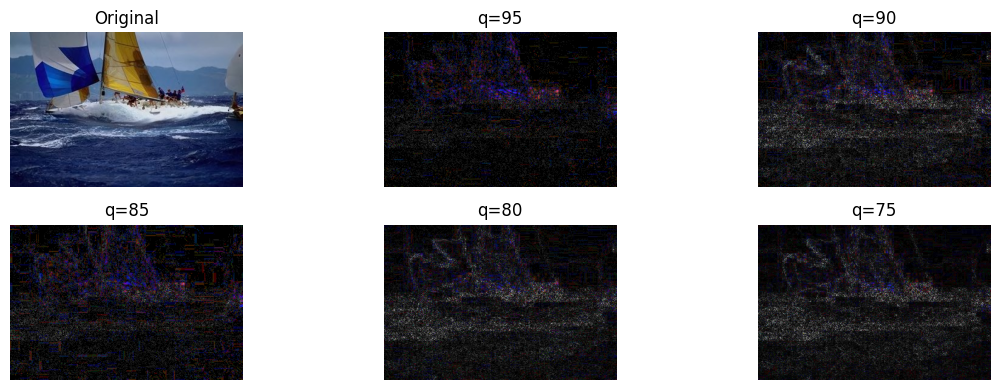

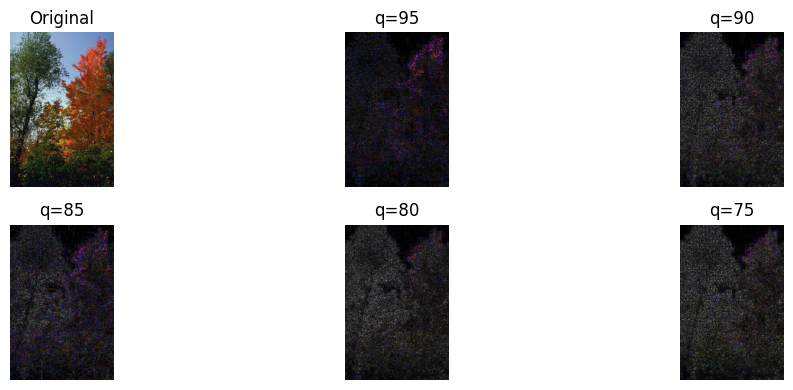

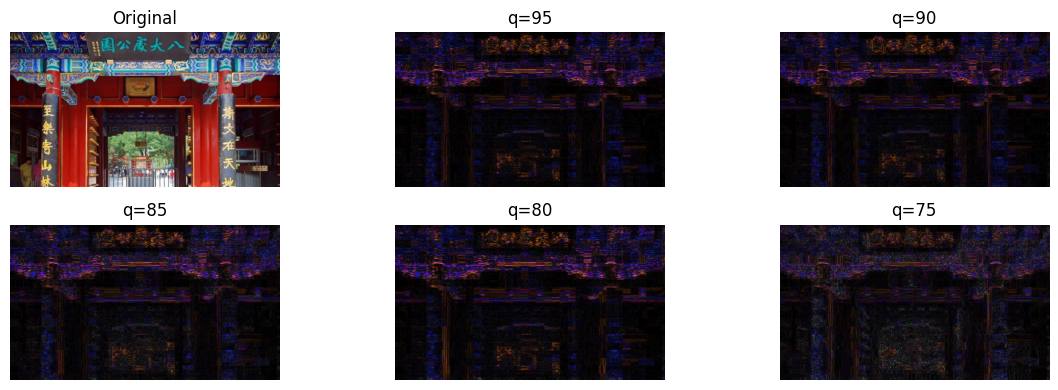

In [5]:
p_list = os.listdir(Real_path)
for _ in range(3):
    random_img = os.path.join(Real_path, random.choice(p_list))
    original   = cv2.cvtColor(cv2.imread(random_img), cv2.COLOR_BGR2RGB) / 255.0
    fig = plt.figure(figsize=(12, 4))
    for idx in range(1, 7):
        quality = 100 - (idx - 1) * 5
        img = convert_to_ela_image(random_img, quality) if idx > 1 else original
        ax  = fig.add_subplot(2, 3, idx)
        ax.set_title(f'q={quality}' if idx > 1 else 'Original')
        ax.axis('off')
        plt.imshow(img)
    plt.tight_layout(); plt.show()


## ELA Visualisation – Tampered Images

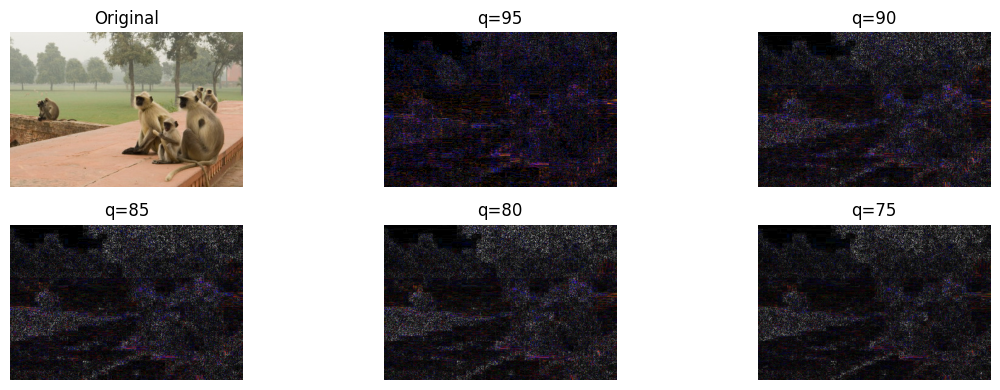

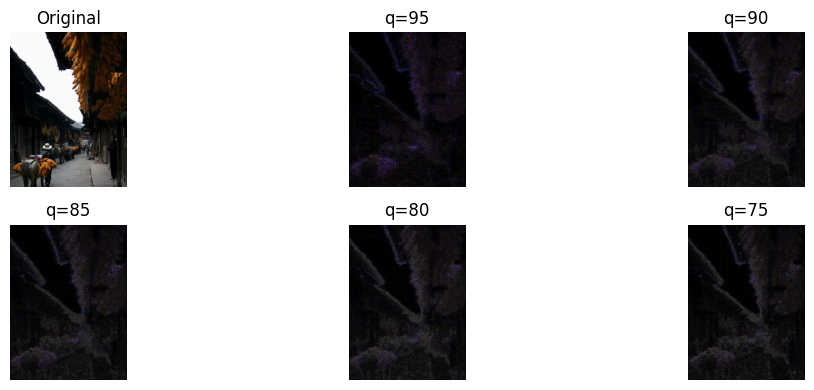

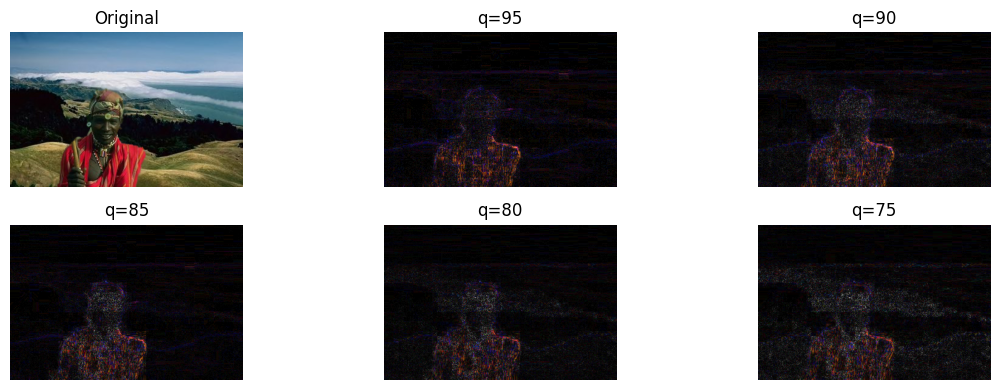

In [6]:
p_list = os.listdir(Tampered_path)
for _ in range(3):
    random_img = os.path.join(Tampered_path, random.choice(p_list))
    original   = cv2.cvtColor(cv2.imread(random_img), cv2.COLOR_BGR2RGB) / 255.0
    fig = plt.figure(figsize=(12, 4))
    for idx in range(1, 7):
        quality = 100 - (idx - 1) * 5
        img = convert_to_ela_image(random_img, quality) if idx > 1 else original
        ax  = fig.add_subplot(2, 3, idx)
        ax.set_title(f'q={quality}' if idx > 1 else 'Original')
        ax.axis('off')
        plt.imshow(img)
    plt.tight_layout(); plt.show()


## Data Preprocessing
Only `.jpg`/`.jpeg` files are used — ELA is only meaningful for lossy JPEG compression.

In [7]:
IMAGE_SIZE = (128, 128)

def prepare_image(image_path, quality=90):
    ela = convert_to_ela_image(image_path, quality)
    return np.array(ela.resize(IMAGE_SIZE)).flatten() / 255.0


## Build Dataset Arrays

In [8]:
X, Y = [], []

for label, folder in enumerate([Real_path, Tampered_path]):
    tag = 'Real' if label == 0 else 'Tampered'
    print(f"Processing {tag} images …")
    for name in os.listdir(folder):
        if name.lower().endswith(('.jpg', '.jpeg')):
            try:
                img = prepare_image(os.path.join(folder, name))
                X.append(img)
                Y.append(label)
            except Exception as e:
                print(f"  Skipped {name}: {e}")
    print(f"  → {Y.count(label)} images loaded")

print(f"\nTotal Real    : {Y.count(0)}")
print(f"Total Tampered: {Y.count(1)}")


Processing Real images …
  → 7437 images loaded
Processing Tampered images …
  → 2064 images loaded

Total Real    : 7437
Total Tampered: 2064


## Reshape, Balance & Split

In [9]:
X = np.array(X, dtype='float32').reshape(-1, 128, 128, 3)
Y = to_categorical(Y, 2)

# Shuffle X and Y together BEFORE splitting.
# Without this, all Real images come first (label=0), so X[:5000]
# contains only Real samples → AUC = NaN, confusion matrix useless.
shuffle_idx = np.random.RandomState(seed=42).permutation(len(X))
X = X[shuffle_idx]
Y = Y[shuffle_idx]

# Hold out 5000 shuffled samples as the test set (both classes present)
X_test, Y_test = X[:5000], Y[:5000]
X,      Y      = X[5000:], Y[5000:]

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, random_state=5)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print(f"Test  — Real    : {int((np.argmax(Y_test, axis=1)==0).sum())}")
print(f"Test  — Tampered: {int((np.argmax(Y_test, axis=1)==1).sum())}")


Train : 3600 | Val : 901 | Test : 5000
Test  — Real    : 3946
Test  — Tampered: 1054


## Save Processed Arrays
Saved to `/kaggle/working/` so they persist after the session.

In [10]:
np.save(os.path.join(ELA_DATA, 'X_train.npy'),  X_train)
np.save(os.path.join(ELA_DATA, 'Y_train.npy'),  Y_train)
np.save(os.path.join(ELA_DATA, 'X_val.npy'),    X_val)
np.save(os.path.join(ELA_DATA, 'Y_val.npy'),    Y_val)
np.save(os.path.join(ELA_DATA, 'X_test.npy'),   X_test)
np.save(os.path.join(ELA_DATA, 'Y_test.npy'),   Y_test)
print("Arrays saved to", ELA_DATA)


Arrays saved to /kaggle/working/ela_outputs/ELA_Data


## Training Config

In [11]:
class Config:
    epochs     = 30
    # Scale batch_size by number of GPUs for MirroredStrategy
    batch_size = 32 * strategy.num_replicas_in_sync
    lr         = 1e-4
    momentum   = 0.95
    nesterov   = False
    n_labels   = 2
    image_size = (128, 128)

print(f"Effective batch size: {Config.batch_size}")


Effective batch size: 64


## Build Model
All layer/model creation must happen inside `strategy.scope()` for multi-GPU training.

In [12]:
METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.AUC(name='auc'),
]

with strategy.scope():
    base_model = DenseNet121(include_top=False, weights='imagenet',
                             input_shape=(128, 128, 3))
    x      = GlobalAveragePooling2D()(base_model.output)
    x      = Dense(1024, activation='relu')(x)
    output = Dense(2,    activation='softmax')(x)
    model  = Model(base_model.inputs, output)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=Config.lr,
                      momentum=Config.momentum,
                      nesterov=Config.nesterov),
        metrics=METRICS
    )

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 8,089,154 (30.86 MB)

 Trainable params: 8,005,506 (30.54 MB)

 Non-trainable params: 83,648 (326.75 KB)

## Callbacks

In [13]:
def lr_scheduler(epoch):
    return Config.lr if epoch < 10 else Config.lr * 0.9

callbacks = [
    LearningRateScheduler(lr_scheduler),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(BEST_MODEL, save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
]


## Train

In [14]:
history = model.fit(
    X_train, Y_train,
    epochs          = Config.epochs,
    batch_size      = Config.batch_size,
    validation_data = (X_val, Y_val),
    callbacks       = callbacks,
)


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 366 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, n

I0000 00:00:1774413883.139776     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774413883.706681     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6948 - auc: 0.7441 - loss: 0.6164INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from inf to 0.63622, saving model to /kaggle/working/ela_outputs/best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 97s 546ms/step - accuracy: 0.6957 - auc: 0.7452 - loss: 0.6152 - val_accuracy: 0.7580 - val_auc: 0.7307 - val_loss: 0.6362 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 

## Save Final Model

In [15]:
model.save(MODEL_PATH)
print("Model saved to:", MODEL_PATH)
print("Best checkpoint :", BEST_MODEL)


Model saved to: /kaggle/working/ela_outputs/ELA_Model.keras
Best checkpoint : /kaggle/working/ela_outputs/best_model.keras


## Results & Analysis

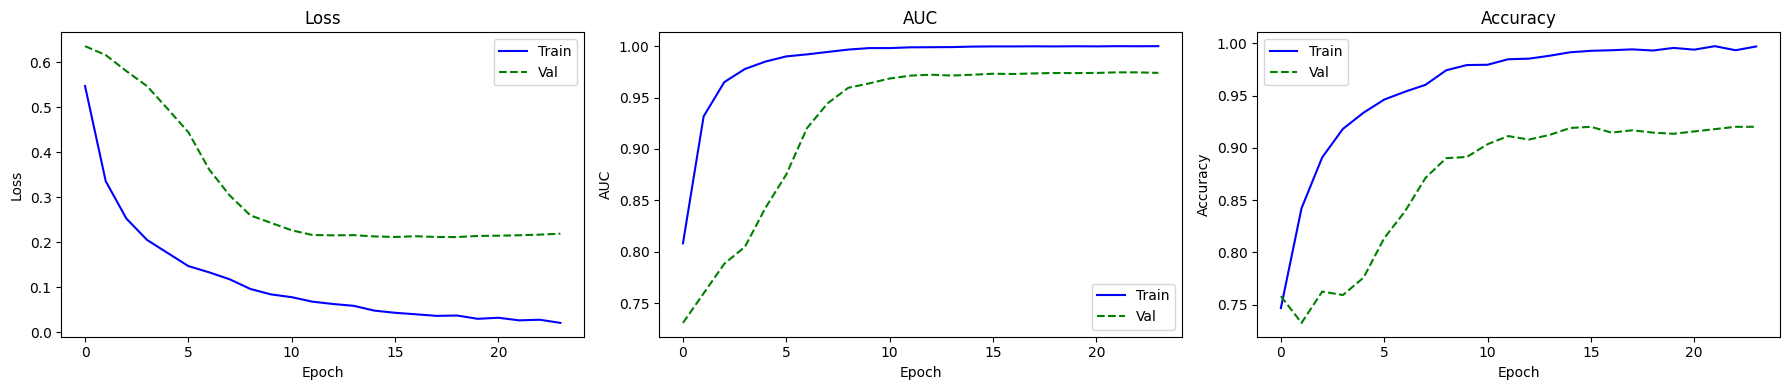

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def plot_metric(ax, metric, title, ylabel):
    ax.plot(history.history[metric],      label='Train', color='blue')
    ax.plot(history.history[f'val_{metric}'], label='Val', color='green', linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend()

plot_metric(axes[0], 'loss',     'Loss',     'Loss')
plot_metric(axes[1], 'auc',      'AUC',      'AUC')
plot_metric(axes[2], 'accuracy', 'Accuracy', 'Accuracy')
plt.tight_layout(); plt.show()


## Confusion Matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step


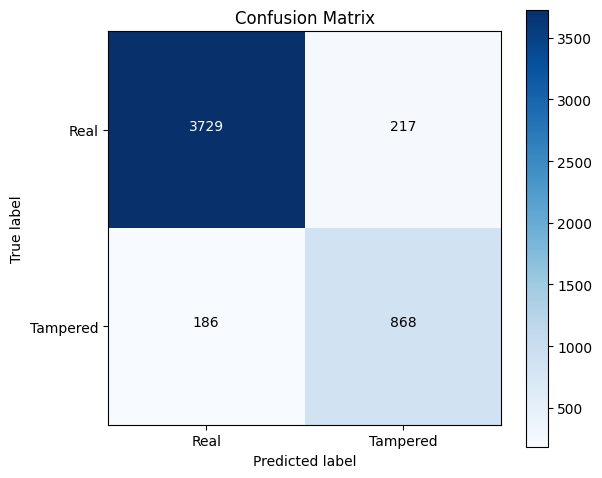


── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

        Real     0.9525    0.9450    0.9487      3946
    Tampered     0.8000    0.8235    0.8116      1054

    accuracy                         0.9194      5000
   macro avg     0.8762    0.8843    0.8802      5000
weighted avg     0.9203    0.9194    0.9198      5000

Test AUC         : 0.9636

── Summary metrics (Tampered as positive class) ────────────────
Accuracy         : 0.9194  (91.94%)
Precision        : 0.8000
Recall           : 0.8235
F1 Score         : 0.8116
True Positives   : 868  (Tampered correctly identified)
True Negatives   : 3729  (Real correctly identified)
False Positives  : 217  (Real wrongly flagged as Tampered)
False Negatives  : 186  (Tampered missed)


In [17]:
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                              classification_report, ConfusionMatrixDisplay)

# Load saved test arrays
X_test = np.load(os.path.join(ELA_DATA, 'X_test.npy'))
Y_test = np.load(os.path.join(ELA_DATA, 'Y_test.npy'))

Y_pred         = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true         = np.argmax(Y_test, axis=1)

# ── Confusion matrix ──────────────────────────────────────────────────────────
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title); plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes); plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True label'); plt.xlabel('Predicted label')

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
plot_confusion_matrix(cm, classes=['Real', 'Tampered'])
plt.show()

# ── Classification report (Precision / Recall / F1) ──────────────────────────
print("\n── Classification Report ──────────────────────────────────────")
print(classification_report(Y_true, Y_pred_classes,
                             target_names=['Real', 'Tampered'],
                             digits=4))

# ── Per-class metrics manually for the report table ──────────────────────────
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

# AUC uses the full probability vector (not argmax) so both classes must be present
try:
    auc = roc_auc_score(Y_test, Y_pred)
    print(f"Test AUC         : {auc:.4f}")
except Exception as e:
    print(f"Test AUC         : could not compute ({e})")

print(f"\n── Summary metrics (Tampered as positive class) ────────────────")
print(f"Accuracy         : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"True Positives   : {tp}  (Tampered correctly identified)")
print(f"True Negatives   : {tn}  (Real correctly identified)")
print(f"False Positives  : {fp}  (Real wrongly flagged as Tampered)")
print(f"False Negatives  : {fn}  (Tampered missed)")
